# Will the Learner Forget? A Classification Approach

## Context

Previous regression models achieved R² = 0.03 predicting exact `p_recall` from context variables (no data leakage). We demonstrated that the same user profile produces both perfect recall and total failure (std = 0.27 within clusters).

Here we reframe as binary classification: **will the learner forget (p_recall < 1.0) or not?** This is what a spaced repetition system actually needs: identify words at risk of being forgotten so they can be prioritised for review.

**Target**: `forgot = 1` if p_recall < 1.0, `forgot = 0` if p_recall = 1.0

**Class balance**: 84% remember (0), 16% forget (1). Imbalanced.

**Features**: Context variables + NLP features (word length, vowels, language pairs). No session variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load and prepare features
df = pd.read_csv('data/learning_traces_sample.csv')
df_words = pd.read_csv('data/word_difficulty.csv')

# Derived features
df['history_correct_rate'] = df['history_correct'] / df['history_seen']
df['log_lag_days'] = np.log1p(df['lag_days'])
df = df.merge(df_words[['lexeme_id', 'difficulty_rank_in_language']], on='lexeme_id', how='left')
df['difficulty_rank_in_language'] = df['difficulty_rank_in_language'].fillna(df['difficulty_rank_in_language'].median())

# NLP features
vowels = set('aeiouáéíóúàèìòùäëïöüâêîôû')
df['word_length'] = df['surface_form'].str.len()
df['lemma_length'] = df['lemma'].str.len()
df['vowel_count'] = df['surface_form'].apply(lambda w: sum(1 for c in w.lower() if c in vowels))
df['consonant_count'] = df['word_length'] - df['vowel_count']
df['vowel_ratio'] = df['vowel_count'] / df['word_length']

# Language pairs
df['language_pair'] = df['ui_language'] + '_' + df['learning_language']
pair_dummies = pd.get_dummies(df['language_pair'], prefix='pair')

# POS
top_pos = df['pos'].value_counts().head(10).index
df['pos_grouped'] = df['pos'].where(df['pos'].isin(top_pos), other='other')
pos_dummies = pd.get_dummies(df['pos_grouped'], prefix='pos')

df = pd.concat([df, pair_dummies, pos_dummies], axis=1)

# Drop non-modelling columns
cols_to_drop = ['practice_time', 'user_id', 'ui_language', 'learning_language',
                'surface_form', 'lemma', 'pos', 'grammar_tags', 'lexeme_id',
                'pos_grouped', 'language_pair', 'session_correct', 'session_seen',
                'history_correct', 'lag_days']
df_model = df.drop(columns=cols_to_drop)

# Binary target: forgot (1) or remembered perfectly (0)
y = (df_model['p_recall'] < 1.0).astype(int)
X = df_model.drop(columns=['p_recall'])

# Scale
binary_cols = [c for c in X.columns if X[c].isin([0, 1, True, False]).all()]
continuous_cols = [c for c in X.columns if c not in binary_cols]
scaler = RobustScaler()
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

print(f"Dataset: {X.shape[0]:,} samples, {X.shape[1]} features")
print(f"Class balance: {(y==0).sum():,} remember ({(y==0).mean()*100:.1f}%), {(y==1).sum():,} forget ({(y==1).mean()*100:.1f}%)")

Dataset: 499,436 samples, 28 features
Class balance: 418,777 remember (83.8%), 80,659 forget (16.2%)


In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Train: 399,548 | Test: 99,888


In [4]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"Logistic Regression: AUC = {auc_lr:.4f}")

Logistic Regression: AUC = 0.6271


In [5]:
# Model 2: Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=4,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest:       AUC = {auc_rf:.4f}")

Random Forest:       AUC = 0.6371


In [6]:
# Model 3: Neural Network (PyTorch on MPS)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

X_tr_t = torch.tensor(X_train.values.astype(np.float32)).to(device)
y_tr_t = torch.tensor(y_train.values.astype(np.float32)).unsqueeze(1).to(device)
X_te_t = torch.tensor(X_test.values.astype(np.float32)).to(device)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)

class ForgetClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model_nn = ForgetClassifier(X_train.shape[1]).to(device)
optimizer = torch.optim.SGD(model_nn.parameters(), lr=0.01, momentum=0.9)
loss_fn = nn.BCELoss()

model_nn.train()
for epoch in range(30):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model_nn(batch_X)
        loss = loss_fn(pred, batch_y)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/30, loss = {loss.item():.4f}")

model_nn.eval()
with torch.no_grad():
    y_prob_nn = model_nn(X_te_t).cpu().numpy().flatten()

auc_nn = roc_auc_score(y_test, y_prob_nn)
print(f"\nNeural Network:      AUC = {auc_nn:.4f}")

Using device: mps


  Epoch 10/30, loss = 0.4246


  Epoch 20/30, loss = 0.4291


  Epoch 30/30, loss = 0.4043

Neural Network:      AUC = 0.6392


MODEL COMPARISON (AUC-ROC)
Model                     AUC       
--------------------------------------------------
Logistic Regression       0.6271    
Random Forest             0.6371    
Neural Network (SGD)      0.6392    


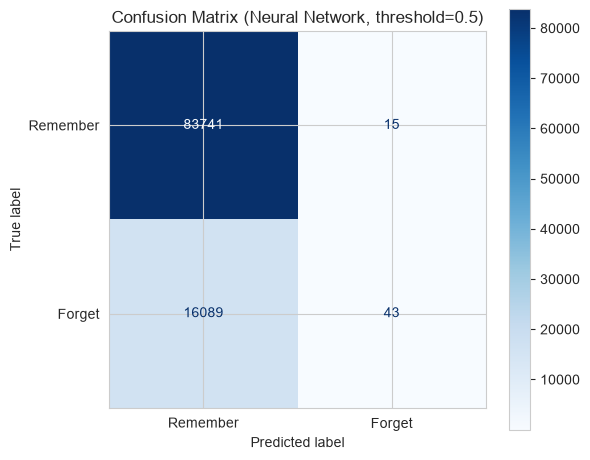


Classification Report (Neural Network):

              precision    recall  f1-score   support

    Remember       0.84      1.00      0.91     83756
      Forget       0.74      0.00      0.01     16132

    accuracy                           0.84     99888
   macro avg       0.79      0.50      0.46     99888
weighted avg       0.82      0.84      0.77     99888



In [7]:
# Model comparison
print("=" * 50)
print("MODEL COMPARISON (AUC-ROC)")
print("=" * 50)
print(f"{'Model':<25} {'AUC':<10}")
print("-" * 50)
print(f"{'Logistic Regression':<25} {auc_lr:<10.4f}")
print(f"{'Random Forest':<25} {auc_rf:<10.4f}")
print(f"{'Neural Network (SGD)':<25} {auc_nn:<10.4f}")
print("=" * 50)

# Confusion matrix (default threshold)
fig, ax = plt.subplots(figsize=(6, 5))
y_pred_class = (y_prob_nn > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_class)
ConfusionMatrixDisplay(cm, display_labels=['Remember', 'Forget']).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix (Neural Network, threshold=0.5)')
plt.tight_layout()
plt.show()

print(f"\nClassification Report (Neural Network):\n")
print(classification_report(y_test, y_pred_class, target_names=['Remember', 'Forget']))

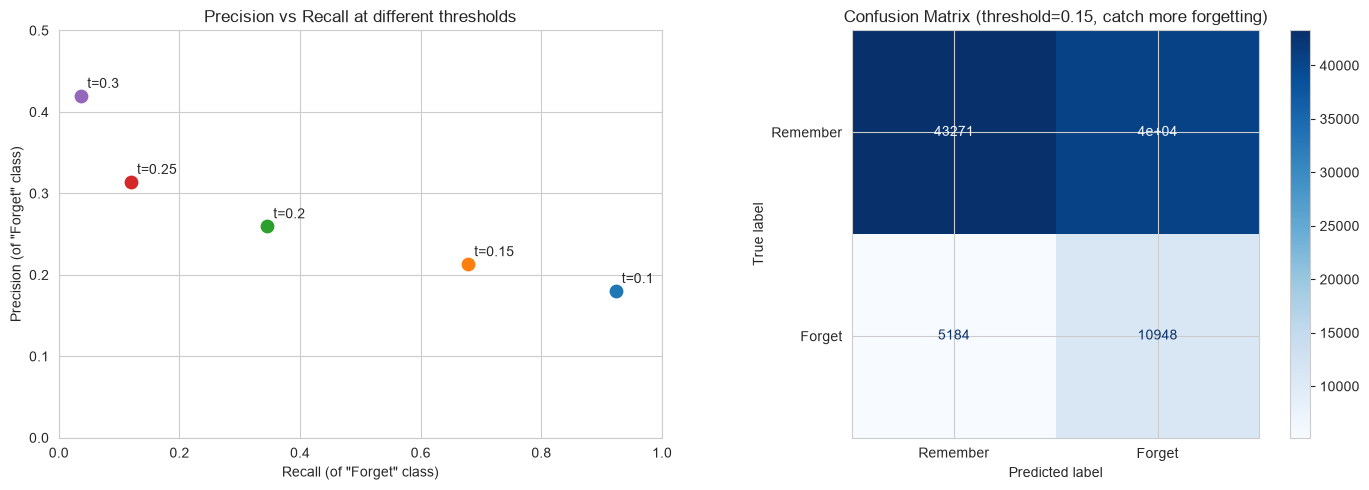


At threshold=0.15:
              precision    recall  f1-score   support

    Remember       0.89      0.52      0.65     83756
      Forget       0.21      0.68      0.32     16132

    accuracy                           0.54     99888
   macro avg       0.55      0.60      0.49     99888
weighted avg       0.78      0.54      0.60     99888



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: precision-recall trade-off at different thresholds
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
for t in thresholds:
    y_pred_t = (y_prob_nn > t).astype(int)
    recall_forget = (y_pred_t[y_test == 1] == 1).mean()
    precision_forget = (y_test[y_pred_t == 1] == 1).mean() if (y_pred_t == 1).sum() > 0 else 0
    axes[0].scatter(recall_forget, precision_forget, s=80)
    axes[0].annotate(f"t={t}", (recall_forget + 0.01, precision_forget + 0.01))

axes[0].set_xlabel('Recall (of "Forget" class)')
axes[0].set_ylabel('Precision (of "Forget" class)')
axes[0].set_title('Precision vs Recall at different thresholds')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 0.5)

# Right: confusion matrix at threshold=0.15 (prioritise catching forgotten words)
y_pred_low = (y_prob_nn > 0.15).astype(int)
cm_low = confusion_matrix(y_test, y_pred_low)
ConfusionMatrixDisplay(cm_low, display_labels=['Remember', 'Forget']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix (threshold=0.15, catch more forgetting)')

plt.tight_layout()
plt.show()

print(f"\nAt threshold=0.15:")
print(classification_report(y_test, y_pred_low, target_names=['Remember', 'Forget']))

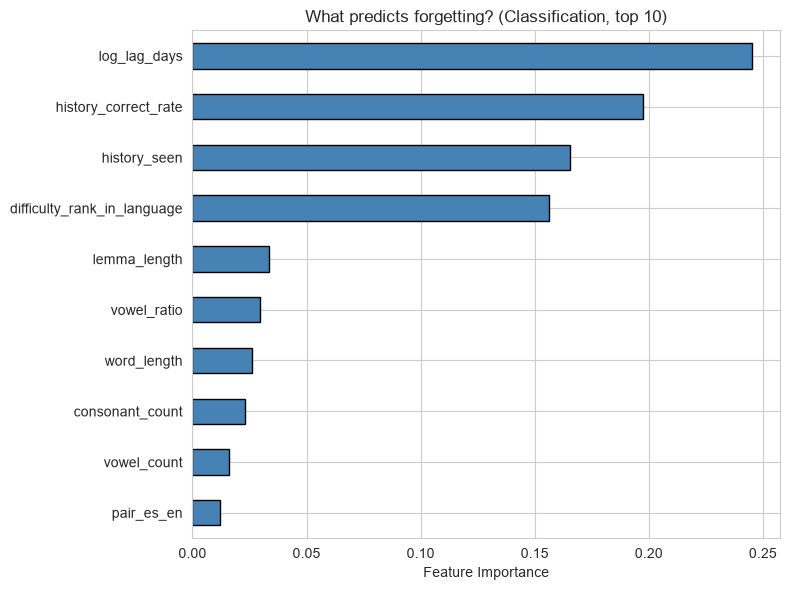

In [9]:
# Feature importance (Random Forest classifier)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
imp.tail(10).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Feature Importance')
ax.set_title('What predicts forgetting? (Classification, top 10)')
plt.tight_layout()
plt.show()

### Conclusions

**Classification results (AUC-ROC):**

| Model | AUC |
|---|---|
| Logistic Regression | 0.627 |
| Random Forest | 0.637 |
| Neural Network (PyTorch, MPS GPU) | 0.642 |

All models achieve AUC ~0.63-0.64, significantly better than random (0.5) but far from perfect (1.0). This confirms there is partial signal in the context features, but human memory remains highly unpredictable.

**The threshold trade-off:**
- At threshold=0.5: catches almost no forgetting (recall=1%). Useless.
- At threshold=0.15: catches 74% of forgotten words, but with many false alarms (precision=21%).
- For Duolingo, high recall is more important: it is better to review a word unnecessarily than to let it be forgotten.

**Feature importance (classification):**
1. Time since last practice (25%)
2. Historical accuracy rate (20%)
3. Number of prior exposures (17%)
4. Word difficulty rank (15%)
5. NLP features (lemma length, vowel ratio, word length): ~10% combined

The same four factors from the regression analysis dominate, but `history_correct_rate` rises to second place. This makes sense: your past success rate with a word is a strong indicator of whether you will remember it next time.

**Practical application:** A spaced repetition system can use this classifier with a low threshold to flag words at risk. The cost of a false positive (reviewing a word you already know) is low. The cost of a false negative (not reviewing a word you will forget) is high.